# Spice
The [Navigation and Ancillary Information Facility](https://naif.jpl.nasa.gov) at the Jet Propulsion Laboratory hosts Spice. This is a free source-available (not open source, they don't accept pull requests) library which JPL uses to transmit and extract solar system geometry and spacecraft trajectories. Spice is probably named after that substance extracted from Arrakis, but being a NASA thing, it got backronymmed:
* (S)pacecraft ephemeris, stored in (S)pacecraft (P)osition (K)ernels, or SPK files.
* (P)lanetary constants, stored in (P)lanetary (C)onstant (K)ernels, or PCK files.
* (I)nstrument information, stored in (I)nstrument (K)ernels.
    This includes things like the field of view size and shape of a remote sensing instrument, antenna, or solar panel.
* (C)amera Matrix information, stored in (C)-matrix (K)ernels.
    This is used to store any time-varying orientation information about any artificial object, such as a spacecraft or instrument on a spacecraft.
* (E)vent information, stored in (E)vent (K)ernels.
    These were heavily used by the Cassini mission, and basically no one else. These were used to store plans, sequences, and events in a timeline format. It's an incredible wealth of data for Cassini and a shame no one else uses it.


## Spice IDs
* Positive for natural bodies, negative for artificial
  * Solar system barycenter is body 0
  * Planet systems are numbered 1-9, with Pluto still considered a planet
  * Sun is body 10
  * Moons are numbered with their planet times 100, plus their moon number. The planet itself is the 99th satellite of its system. So we have:
     * 3 is Earth-Moon system
     * 301 is Moon
     * 399 is Earth
  * Numbered asteroids and comets each have a designated range
* Spacecraft are negative. Interplanetary spacecraft have an ID in the range -1 to -1000, with the authority being JPL NAIF. Voyagers are -31 (Voyager 1) and -32 (Voyager 2)
  * Numbered Earth satellites have an ID range, -100000-NORAD_ID, so AIM would be -131304
  * Parts of spacecraft (instruments) have ID*1000-instrument code, so Voyager 1 ISS NAC is -31101 since the Voyager ID is -31 and the NAC code is 101.

## SPK
These files record the position and velocity of a spacecraft with exquisite position. They are the industrial grade precision required to accurately navigate to a planet, and are publicly available. If we want to know where Voyager 1 was on 1979-03-05 at 01:23:45 UTC, the right SPK will tell us to millimeter precision and as much accuracy as the spacecraft and ground track network are capable of. Planets and moons get the same kind of position support, so their trajectories are also recorded in SPK files, not PPK files as one might guess.

There are many kinds of SPK files, but the kind doesn't really matter to the user. In all cases, the right way to think about it is that each SPK file has a table of time vs position and velocity at discrete samples, and a method of interpolating that data to enable recovery of the position at any time. For instance, the type 13 SPK file is literally this -- a table of TDB times and associated 3D position and 3D velocity. For times in between the samples, it is required to use Hermite polynomials of a given order to do the interpolation, and there is enough information in the table to create such polynomials.

Kernel types only matter to the creator. In all cases, we can conceptually imagine the table of discrete state vectors being used to construct a function of continuous state vectors over a continuous time range. The correct interpolation for each kernel type is built into the Spice library, and there is enough information in the spice kernel such that the library can automatically choose the interpolation. For the user, it Just Works(TM).


### Voyager Kernels

### Use in Magrathea: `furnsh()` and `spkezr()`
In Magrathea, we follow my advice and just let the library do the work. We load:
* A spice kernel describing the position of Jupiter and its satellites relative to the Jupiter system barycenter
* A spice kernel describing the position of the Sun and all the planet system barycenters (including Jupiter and Earth) relative to the solar system barycenter
* A spice kernel describing the position of the spacecraft. It is relative to *something*, but we as users don't care, as we shall see
* Various other kernels to describe clocks and frames as necessary.

Magrathea is specifically for Voyager (for now) and therefore uses the following specific kernels:
* `voyager_1.ST+1991_a54418u.merged.bsp` -- "Supertrajectory" providing at least low-accuracy position for the entire mission from shortly after the Earth departure burn to far into the future.
* `vgr1_jup230.bsp` A detailed science-grade trajectory for the Voyager 1 Jupiter encounter, developed along with the JUP230 satellite ephemeris. JUP230 and the matching Voyager encounter are curve fits through all relevant Voyager data including opnav photos and ranging data when available, and all relevant position data from all sources but including the Voyager 1 observations. The Voyager and satellite trajectories were fit through all available data simultaneously and produce consistent trajectories. It is important to carefully match the trajectory and satellite data for best accuracy. Different (newer) fits might fit other times better, but Voyager itself is the best available data for the Voyager encounter timeframe, so it's not expected that this will improve the Voyager encounter, only later times. JPL occasionally does new analyses with both new and old data, and at that time, an updated Galilean ephemeris and Voyager trajectory will become available.

There is a similar supertrajectory for Voyager 2, and for each encounter by each spacecraft.

For Magrathea, we use `de440.bsp` as the best available planetary kernel. The current solar system kernels are so good that any variation from one to another these days will be on the kilometer or less scale in historically interesting times. We use `vgr1_jup230.bsp` as the best available trajectory for Voyager 1 during the Jupiter encounter. It is designed to match up with the `jup230l.bsp` kernel for positions of the Galilean satellites, so that's the one we use. 

With these kernels furnished, we can query the position of things in our own natural framework. For instance, "Where is the spacecraft relative to Jupiter at closest approach?"

In [ ]:
from spiceypy import furnsh, spkezr, str2et
from kwanmath.vector import vlength
spice_root="../data/spice"
furnsh(f"{spice_root}/lsk/naif0012.tls")    # "Leap second" kernel allows us to use UTC
furnsh(f"{spice_root}/spk/de440.bsp")       # Background solar system kernel, tracks position of Sun and planet system barycenters
furnsh(f"{spice_root}/spk/jup230l.bsp")     # Position of Jupiter and the Galilean satellites relative to the Jupiter barycenter
furnsh(f"{spice_root}/spk/vgr1_jup230.bsp") # Position of Voyager during the Jupiter encounter, reconstructed using the JUP230 satellite ephemeris
et_ca=str2et("1979-03-05 12:05:26 TDB")     # Time of closest approach, not pulled from the kernels but instead from https://science.nasa.gov/mission/voyager/planetary-voyage/#hyperbolic
state,lt=spkezr("599",et_ca,"J2000","NONE","-31") # Position and velocity of Jupiter (object 599) at the given time, in J2000 oriented frame, with no geometric corrections, as seen from Voyager 1 (object -31).
pos,vel=state[:3].reshape(-1,1),state[3:].reshape(-1,1)
print(f"{pos=}\ndist={vlength(pos)} km\n{vel=}\nvel={vlength(vel)} km/s")

This is the best available accuracy to *anyone* and is definitely professional grade, suitable for any level of scientific analysis or navigation engineering.

In the actual code, we do something like this:

In [ ]:
from magrathea.doc import display_literate_code
display_literate_code('../scripts/v1j.py','spice_furnsh')

In [ ]:
display_literate_code('../scripts/v1j.py','spkezr')


## PCK
Planetary constant kernels record sizes and rotation states of every (natural) object in the solar system with a known size and rotation state. This includes the Sun, all the planets (including Pluto), all moons with known sizes and rotations, and all asteroids with known sizes and rotations. Almost all moons have size and rotation models, while almost all asteroids don't yet. Other constants can be associated with each planet, for instance mass (GM) or gravity field coefficients (J2). JPL NAIF publishes an updated version with the best available constants, copied out of an IAU report. The latest one is `pck00011.tpc`.

For each body, there will be a variables like this:
```

        BODY501_POLE_RA       = (  268.05          -0.009      0. )
        BODY501_POLE_DEC      = (   64.50           0.003      0. )
        BODY501_PM            = (  200.39         203.4889538  0. )
        BODY501_LONG_AXIS     = (    0.                           )

        BODY501_NUT_PREC_RA   = (    0.   0.     0.094    0.024   )
        BODY501_NUT_PREC_DEC  = (    0.   0.     0.040    0.011   )
        BODY501_NUT_PREC_PM   = (    0.   0.    -0.085   -0.022   )

        BODY501_RADII     = ( 1829.4   1819.4   1815.7  )
```
Spice has a built in frame for Io, `IAU_IO` that uses the constants in the PCK to determine the orientation of Io relative to some global frame. Therefore `IAU_IO` is an available body-fixed frame as long as some kernel that supports this model is present. There are a large number of such frames, all of the form `IAU_<body_name_in_all_caps>`

### Great Red Spot
Note that for the gas giants, we have up to 3 different rotation systems, tracking different parts of the planet which can rotate at different rates. For Jupiter, we have:
* System I -- "refers to the mean atmospheric equatorial rotation". In another context, I have heard within 10deg of the equator.
* System II -- "refers to the mean atmospheric rotation north of the south component of the north equatorial belt, and south of the north component of the south equatorial belt". In practice this means the *entire cloud tops* except for the equatorial zone. Particularly for our purposes, it represents the great red spot.
* System III -- tracks the rotation of the magnetic field. This is often portrayed as the "real" rotation of the bulk of the planet, beneath what is visible at the cloud tops.

All of these are purely defined by convention -- Each is constructed by fitting a linear rotation model through tracked points in either the equatorial zone or great red spot. However, once the linear fit is made, it is established by convention and no longer needs to refer to anything real in the atmosphere.

Of note is System II. The great red spot on Jupiter is the most notable feature there, and it rotates with the System II region. The location of the great red spot with respect to System II has been [tracked for decades](view-source:https://jupos.hier-im-netz.de/img/oRS19b.gif) so we can find where it was during the Voyager encounters. During 1979, the great red spot was 59deg west of the System II prime meridian. Here we see that while System II was designed to follow the great red spot, and it does with great accuracy, the spot itself doesn't move uniformly.

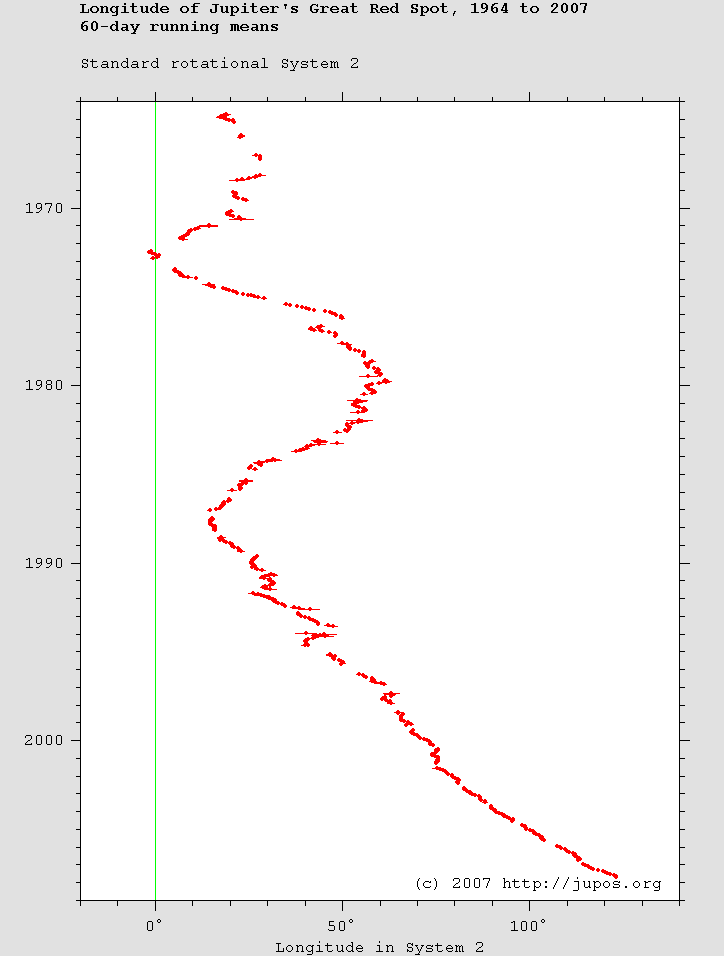

Spice can only represent one rotation system for a given planet. Sure, you can define a frame kernel to track any particular set of rotation constants, but for instance IAU_JUPITER has one and only one definition, using BODY599 rotation constants. For their own purposes, the lords of the Spice have decided to use System III models for all the gas giants. Therefore, for all planets, Jupiter included, the IAU_<body name> frame is System III. For Saturn and Uranus, this hardly matters since the planets are much smoother and there are no widely known features that have the same attention in the public mind as the great red spot. For Neptune, there's the great dark spot so we need care there as well. IAU_<body name> is built into Spice, but the coefficients it uses are from a PCK, and we can change the PCK files. In particular, one notable thing about Spice is that data which is furnished later "covers up" data furnished earlier. If there is multiple definitions of the same thing, and they contradict each other, the latest one furnished "wins". So, we can load `pck00011.tpc` to get the vast majority of the rotation data, then a special kernel that just overrides one set of coefficients. When we later use Spice to evaluate IAU_JUPITER, it will find our modified constants and use whatever system that encodes.

In [ ]:
display_literate_code('../data/spice/pck/jupiter_system2.tpc',language='')

To render Jupiter with a single texture map, we then:
* Load `pck00011.tpc` and `jupiter_system2.tpc`. This makes IAU_JUPITER track System II, but leaves all other planetary constants at their original values.
* Get the [best map of Jupiter](https://bjj.mmedia.is/data/jupiter_vgr1/index.html) available. The referenced image is made from Voyager 1 mosaics on 1979-02-27, a few days before closest approach. The compositer chose to orient the map in System III.
* Rotate it so its picture of the red spot is at the prime meridian
* Rotate it further such that the spot is 59deg west of the prime meridian
* Project it like an ordinary texture map using the Spice IAU_JUPITER

## Instrument and Frame kernels
### Instrument Kernels
Instrument kernels are used to define the field of view of an instrument, relative to its own natural frame. Cameras often have the following frame:
* +Z is in the view direction (boresight)
* +X is parallel to horizontal edge of detector, with positive to the right
* +Y completes the right-handed frame, so is parallel to vertical edge with positive increasing down.

The field of view is then described with a set of vectors for each corner of the field of view in this instrument frame. There are shortcuts for when the FOV is a simple shape, like rectangle or cone.

Any coefficients for an instrument can be stored here, including such things as corners of a non-simple FOV polygon, instrument distoriton model coefficients, instrument calibration coefficients, etc. Since Spice was applied retroactively to Voyager, they only include the minimum, in this case a square field of view approximation.

### Frame Kernels
Frame kernels define the relative orientation of particular coordinate frames relative to other ones. There can be a whole tree of frames -- the camera on Voyager is mounted on the scan platform, which is mounted on the elevation actuator, which is mounted on the azimuth actuator on the science boom mounted on the spacecraft. So a frame kernel says that the camera is mounted on the scan platform with a measured offset, the scan platform is mounted on the elevation actuator with this time-varying history of motion, derived from spacecraft telemetry. The elevation actuator in turn is mounted on the azimuth actuator with its time history of motion, and the azimuth actuator is mounted on the spacecraft, with it's time varying orientation relative to the larger inertial frame. This requires a frame kernel with entries for camera, platform, actuators, and spacecraft. This frame kernel in turn requires and points to time history tables of motion, which are supplied by CK files.

## C-Matrix Kernels
For historical reasons, orientation is thought of as a "camera matrix" which transforms points in some other frame into the frame aligned with the camera frame. Since everything is in motion and since some of these are controlled in arbitrary patterns, we have a kernel which 

## Spacecraft Clock kernels and Leapsecond kernels
### SCLK kernels
  These record the measured relation between the spacecraft timestamp for events and some real-world clock. If a spacecraft needs to take a picture at a certain time, you don't just say to take the picture at 12:00. You have to convert it to onboard format, and SCLK can help with that. Similarly when that spacecraft takes the picture and sends it down, saying it took the picture at 1/72457180:12345, SCLK helps convert that to 12:00.

  On Voyager, the primary clock is centered around the Imaging Subsystem (ISS) camera. It can take and transmit a picture once every 48 seconds. It has a resolution of 800 lines. In order to transmit a picture every 48 seconds, the spacecraft clock is built with a counter that ticks once each line can be transmitted and rolls over at 800 in 48 seconds. Each rollover is counted, in a counter that can count from 0 to 59 and roll over at 60. When it rolls over in turn, it is counted in a 16-bit counter. When *that* third counter rolls over, it just rolls back to 0 without another counter on the spacecraft. That last rollover is recorded on the ground, however, as a "segment" count. So on Voyager, time is counted in a form that looks like `1/22222:33:444` where the first segment count grows without limit, the second field counts from 0 to 65535, the third counts from 0 to 59 and ticks once every 48 seconds, and the fourth counts from 0 to 799.

  It has become customary to build spacecraft with a clock which is roughly in line with TDB. It has a 32-bit second counter and a 16 or 32 bit subsecond counter. For instance, most NASA Mars probes have a 16-bit subsecond counter, which counts from 0 to 65535 in 1 second and rolls over from 65535 back to 0. That rollover is counted in the 32-bit second field, which only rolls over every 4 billion seconds or over 100 years, long past the design life of all current missions. The clock is set so that its second counter is 0 on 2000-01-01, *no matter when* the spacecraft launches. In this case, the clock will never roll over, and new segments are only counted (on the ground) if the clock is interrupted or reset.

  The spacecraft clock is used by the spacecraft hardware to timestamp all telemetry, including the time an image is taken at and the time an orientation measurement is made. It is designed to be very accurate, but is known to not be perfectly accurate. One process that the ground system has to perform is "time correlation". In principle it works like this:
    * The spacecraft is sent a command to send back the current time. This command leaves Earth at a well-known time, measured by the atomic clock or GPS receiver at the ground station antenna.
    * The spacecraft receives the command, interprets it, looks up the timestamp, encodes that timestamp, and sends it back. This process takes a short, and more importantly *known* amount of time that is carefully designed and measured on the ground before launch.
    * The ground station receives the packet with the timestamp and marks the exact time of reception using its clock.
  This measures the clock on the spacecraft relative to the ground at one time. Using all the trajectories, light times, taking into account special and general relativity, etc, the ground figures out the accurate TDB that the spacecraft transmitted the timestamp, and associates that spacecraft time with that TDB. Multiple such measurements can measure the rate of the on-board clock and its drift from nominal. This drift can just be measured (free-running clock), or have its frequency tuned to return to nominal (disciplined clock). A spacecraft clock can be reset, but usually isn't, as it causes lots of headaches on the ground. If it is necessary to make the clock match its nominal rate, we usually do that by tuning the frequency and *steering* the clock back to nominal.

  All clock operational decisions are made by the ground segment, and to users it generally doesn't matter. A telemetry user, like us looking at image or attitude timestamps, will often run across a timestamp in spacecraft clock format. In this case, *just use the clock kernel*. A string timestamp is converted to TDB with `scs2e()` (spacecraft clock string to ET). A binary encoded timestamp like a 32-bit int seconds and 16-bit subseconds is first converted to a string, with a segment added on if needed, then converted with `scs2e()`.

### Leapsecond kernel
  This stores information needed to convert from the civil UTC time scale to the scientifically useful TAI (international atomic time) and TDB time scales. UTC (coordinated universal time) and its older name Greenwich Mean Time, is often thought of as "official" or "scientific" and it is, but it's important to note that UTC tracks the rotation of the Earth. The Earth itself is not a perfect clock. Our civilization has maintained a series of atomic clocks, starting in about 1958, which keep better time than the Earth. Since then, the rotation of the Earth has been carefully tracked by tracking quasars. The quasars are far enough away that they have no motion across the sky (proper motion). They are tracked by radio telescopes on the ground, which therefore rotate with the Earth. Each telescope marks its observations based on an atomic clock which can be tracked to TAI -- most commonly this is done by GPS these days. In this way the orientation of the Earth at any given time is measured with milliarcsecond accuracy. Each day it rotates 360deg relative to the Sun in 24h00m00.000s, off by a couple of milliseconds at most. But, if the Earth has 1000 days of being slow by 1ms each day, that adds up to one second. At this point, we add a "leap second" to UTC, in between 23:59:59 and 00:00:00. These are planned months in advance and make news when they happen, and as of this writing (September 2025) it makes news when a leap *doesn't* happen. TAI and UTC were in sync on 1958-01-01, near the time when the suite of atomic clocks started running. We have a complete atomic time scale from then to now. As of this writing, TAI is 37 seconds ahead of UTC because the Earth has been slow and has lagged that much time over the nearly 70 years since the atomic time scale started.

  LSK file also record the information necessary for the TDT (terrestrial dynamic time) and TDB (barycentric dynamic time) scales. TDT is the ideal that TAI strives for -- a perfect atomic clock sitting on the surface of the Earth, with all of the motion and overlapping gravity wells at this point taken into account. The TAI clock is designed to tick at the SI rate of 9.1GHz, and does with exquisite precision and accuracy, but it's not perfect. TDT is the ideal perfect clock that TAI strives to be. All observers can in principle see the TAI clock, and see that every 9.1 billion cesium ticks, the clock advances by one second of its own proper time. One interesting thing is that since we don't have a better clock than TAI, for mere mortals, TAI and TDT *do* tick at the same rate because TAI *is* perfect at the level we can tell without our own (better) clocks. TDT was set to match UTC on 1900-01-01, which can be done because the orientation of the Earth at that time is the result of a curve fit from very accurate observations made for decades around that date by the competent astronomers. TDB can be thought of as a time scale that is parallel to TDT but is rigorously usable across the whole solar system in a general relativity sense. There's a bunch of layman hand-waving, but TDB is a uniform time scale as seen by a clock at the solar system barycenter but not affected by the gravity well of the sun and planets. The way I've heard it explained is to imagine an atomic clock on a spacecraft moving parallel to the solar system barycenter, matching all its wiggles, but far enough away from the solar system such that gravitational time dilation doesn't happen. TDB *does not* tick in SI seconds, at least not at the point where it is defined. A clock that ticks at the SI rate out there keeps TCB, coordinate barycentric time. Because it's up out of a gravity well and the Earth is orbiting and rotating relative to it, observers on the Earth do not see the clock tick at 1 second per second. There is a linear transformation from TCB to a scale which over a long term average *does* tick at 1 second per second as observed from the Earth, and this is TDB, dynamic barycentric time. For our purposes, TDB is the time scale with all of general relativity taken care of so we don't have to think about it. It is thought of as UTC (with a few second offset) which is usable anywhere in the solar system.

## CK
For historical reasons, the orientation of an instrument is called a "camera matrix" or C-matrix. Therefore the C-matrix kernel records time-varying orientation of one instrument in relation to another frame.

A frame is a set of basis vectors and an origin, but often the origin doesn't matter. At its root, Spice has the J2000 frame, with its origin at the solar system barycenter. This is practically realized by the DE4xx kernels, but intended to match the FK5 ICRF to a very high precision. It is believed that Spice J2000 *does* match ICRF to milliarcsecond precision, a level barely detectable even with the best VLBI measurments, and good enough for all practical spacecraft problems.

From J2000, there are a number of built-in and custom frames. Each frame is at some offset from its upstream frame, with J2000 at the root. Each frame has a method of defining its orientation relative to its parent, and of defining its origin. Some of the built-in frames include body-fixed frames for each planet and minor body with a known rotation state. The custom frames are generally provided with respect to a given mission or spacecraft. The frame kernel for the mission will define its own tree of frames, each with a parent and some way of determining the orientation. These include:

* Fixed offsets, with a matrix, quaternion, or Euler angle defining the offset. For instance, EMM/EXI had a nominal orientation relative to the spacecraft body. EXI was aligned such that its axes are parallel with the detectors. There is a nominal orientation from the drawings, but then an actual orientation once the instrument is bolted onto the spacecraft and measured.
* Dynamic frames, for instance an alongtrack-crosstrack-radial frame. This might be centered on and follow the motion of a spacecraft or other object, relative to a parent object. These need enough data (almost certainly SPK files) to track the motion of the relevant objects.
* CK frames. These are the most important and sometimes the most complicated. They describe an explicit orientation of this frame relative to its parent as a function of time. The function of time is provided by a CK file. So, in order to use a CK frame, we need both an FK to define the frame and say it needs a CK, then a CK with the correct objects to provide the actual time-varying data.

A CK file has a certain *coverage*. This is the set of times for which this file provides an orientation value for. For instance, a mission ops center (MOC) might produce a daily or weekly CK file which reports the measured orientation of the spacecraft continuously over the week. In actuality, it is a set of discrete orientations at discrete times, but with designated rules for interpolating between the times.

A simple spacecraft like EMM/EXI has all of its instruments bolted down to the spacecraft, so that only the orientation of the spacecraft itself is needed. Other more complicated spacecraft have more frames and need more CK files:

* Voyager has the spacecraft orientation, the scan platform orientation, and fixed kernels based on text FK files for the orientation of each instrument on the scan platform.
* Maven/IUVS has an articulated pointing platform, with three gimbal axes. The spacecraft MOC provides a kernel for the spacecraft and each gimbal axis. IUVS itself has a scan mirror whose angle must be taken into account as well. IUVS ITF parses the instrument telemetry and produces a CK for the scan mirror. Then with the spacecraft orientation, all three gimbal angles, and the instrument scan mirror angle, the pointing of the IUVS field of view can be found.

SPK files have a native time scale of TDB, since spacecraft are navigated *from Earth*. The Deep Space Network provides tracking, which is exactly what it sounds like -- a track (trajectory) of the spacecraft. CK files on the other hand have a native time scale of local SCLK. This is because the measurements of spacecraft attitude and telemetry for actuator motion are captured on board, timestamped with the spacecraft clock. Therefore to use a CK file you must almost always need a correct SCLK kernel.

For Magrathea, we use several sources of orientation:
* `vgr1_super.bc` -- This is the orientation of the spacecraft bus relative to a universal frame (`ECLIPB1950` in this case) over nearly the entire mission. Span between samples is variable, but is best where we need it most, near encounters.
* `vg1_jup_qmw_na.bc` and `vg1_jup_qmw_wa.bc` -- these are generated by the Astronomy Unit at the Queen Mary and Westfield (QMW) college of the University of London. They are a spice encoding of the Supplemental Experiment Data Record (SEDR), basically all the instrument telemetry which isn't an image pixel or science measurement. It includes an estimate of the orientation based on the AACS telemetry, and these files are raw transcripts of those estimates, at the time of each narrow angle (na) or wide angle (wa) image. There is no attempt to correct any errors in the SEDRs.
* `vg1_jup_version1_type1_iss_sedr.bc` -- Another transcript of the SEDRs, providing discrete (type1) uncorrected (version1) pointing instances at the times of the NAC exposures.
* `v1j_slew.bc` -- These are done by me, to attempt to provide actual elevation and azimuthal slewing for the scan platform in between NAC images. This is based on the SEDR kernel above.
* `vg1_v02.tf` -- frame kernel for Voyager 1, including relative orientation of instruments on the scan platform.

## EK
All I can say about event kernels (EK) is that:
* They were extensively used by Cassini, and no one else.
* They look like they should have interesting things in them like experimenters manual notes, planned and/or executed sequences, etc, all on a timeline.

It looks to me like something I *should* want from all missions, but seem to be Cassini-centric. Cassini was the mission that was developed around the time Spice was.

## Metakernels
The metakernels contain lists of kernels to load, so I can say "Load *all* of the best kernels for Voyager 1".

## Using the kernels
One of the most important things to note about Spice is that it is battle-tested, professional grade software. It is well tested and used in various production environments. If it has errors, you will hear about it in the evening news when a spacecraft crashes. Therefore *trust it*. Use the highest-level tool in the Spice library. For instance, here is the Less Effective(TM) way to use kernels:
* Parse the double-array file (DAF)
* Build interpolators for all relevant Spice types
* Get sclk and lsk correct
* Convert the desired time to sclk correctly
* Find the chain of frames from what you want to what you have.
* Correctly evaluate all the frames
* Correctly concatenate all the frames
  
Slightly more effective, but still Less Effective(TM):
* Figure out the chain of frames
* Use spice `ckgpav()` to get the orientation of each frame
* Correctly concatenate the frames

Effective(TM):
* Use `M_tf=pxform('from','to',et)` to get orientation of `from` frame in `to` frame
* `v_to=M_tf@v_from`

Super-Effective!(TM):
* Forget matrices entirely
* `spkezr('target',et,'observer_camera_frame','LT+S','observer') to get the location of the target *already in the camera frame*